!nvidia-smi

In [1]:
import tensorflow as tf

# ==========================================
# 1. KAGGLE DATASET PATH
# ==========================================
# Points to the attached Kaggle dataset directory
DATASET_PATH = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train'

# ==========================================
# 2. HYPERPARAMETERS
# ==========================================
IMG_SIZE = 224  # CRITICAL: Must be 224 for the pre-trained ViT
BATCH_SIZE = 32

# ==========================================
# 3. DATA PIPELINE
# ==========================================
# Create the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH, 
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# Create the validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# Performance Optimization (Utilizing Kaggle's 30GB RAM)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

2026-03-21 14:43:03.345074: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774104183.578396      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774104183.640093      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774104184.172272      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774104184.172333      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774104184.172337      24 computation_placer.cc:177] computation placer alr

Found 39209 files belonging to 43 classes.
Using 31368 files for training.


I0000 00:00:1774104231.276021      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774104231.281965      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 39209 files belonging to 43 classes.
Using 7841 files for validation.


Loading data from Kaggle Input...
Found 39209 files belonging to 43 classes.
Using 31368 files for training.
Found 39209 files belonging to 43 classes.
Using 7841 files for validation.

Starting Training...
Epoch 1/10


I0000 00:00:1774104310.954824      74 cuda_dnn.cc:529] Loaded cuDNN version 91002


491/491 ━━━━━━━━━━━━━━━━━━━━ 97s 141ms/step - accuracy: 0.0485 - loss: 4.3542 - top-5-accuracy: 0.2238 - val_accuracy: 0.0570 - val_loss: 11.5534 - val_top-5-accuracy: 0.2870
Epoch 2/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 65s 133ms/step - accuracy: 0.0559 - loss: 3.4910 - top-5-accuracy: 0.2658 - val_accuracy: 0.0657 - val_loss: 11.4318 - val_top-5-accuracy: 0.3035
Epoch 3/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 65s 133ms/step - accuracy: 0.0540 - loss: 3.4862 - top-5-accuracy: 0.2710 - val_accuracy: 0.0658 - val_loss: 11.4961 - val_top-5-accuracy: 0.2847
Epoch 4/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 64s 131ms/step - accuracy: 0.0558 - loss: 3.4911 - top-5-accuracy: 0.2731 - val_accuracy: 0.0656 - val_loss: 12.7567 - val_top-5-accuracy: 0.2986
Epoch 5/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 65s 133ms/step - accuracy: 0.0532 - loss: 3.4927 - top-5-accuracy: 0.2684 - val_accuracy: 0.0664 - val_loss: 13.2333 - val_top-5-accuracy: 0.3102
Epoch 6/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 64s 130ms/step - accuracy: 0.0565 - loss:

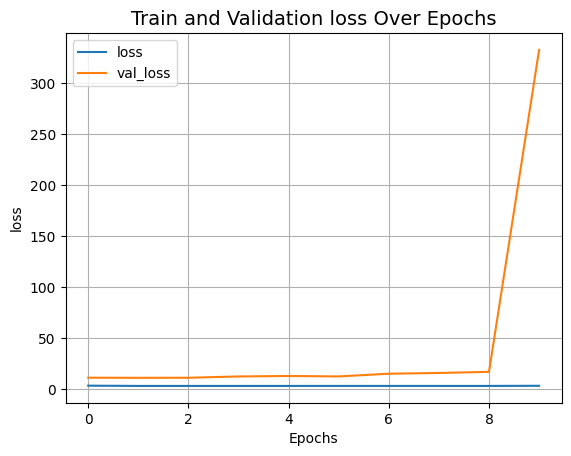

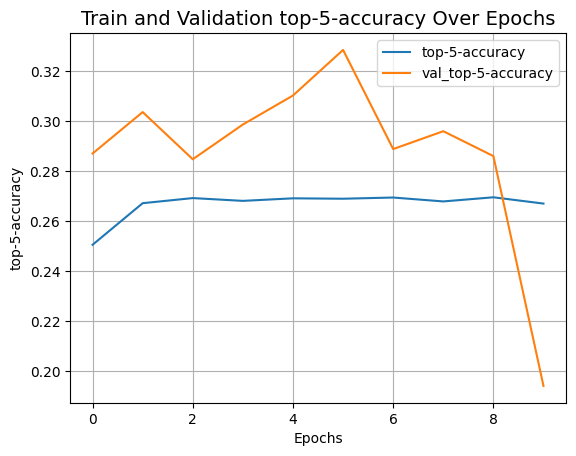

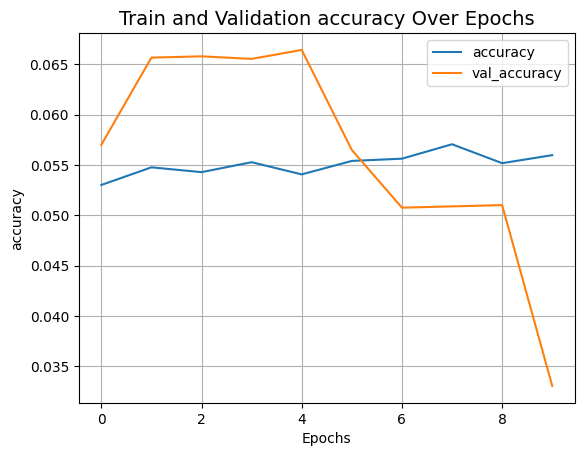

In [2]:
"""
Title: Image classification with Vision Transformer
Author: [Khalid Salama](https://www.linkedin.com/in/khalid-salama-24403144/)
Adapted for Kaggle GTSRB Environment
"""

import os
# 1. KAGGLE ADAPTATION: Use TensorFlow backend for GPU stability
os.environ["KERAS_BACKEND"] = "tensorflow"  

import keras
from keras import layers
from keras import ops

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ==========================================
# HYPERPARAMETERS & SETUP
# ==========================================
num_classes = 43 # GTSRB has 43 traffic sign classes
input_shape = (72, 72, 3)

learning_rate = 0.001
weight_decay = 0.0001
batch_size = 64  # Safe batch size for dual T4 GPUs
num_epochs = 10  # 10 for testing, change to 100 for final run
image_size = 72  # We'll resize input images to this size
patch_size = 6   # Size of the patches to be extract from the input images
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4
transformer_units = [
    projection_dim * 2,
    projection_dim,
]  # Size of the transformer layers
transformer_layers = 8
mlp_head_units = [
    2048,
    1024,
]  # Size of the dense layers of the final classifier

# ==========================================
# 2. KAGGLE DATA PIPELINES
# ==========================================
# Updated to the exact Kaggle dataset path
DATASET_PATH = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train'

print("Loading data from Kaggle Input...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(image_size, image_size),
    batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(image_size, image_size),
    batch_size=batch_size)

# Cache and prefetch utilizing Kaggle's 30GB RAM
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ==========================================
# DATA AUGMENTATION
# ==========================================
data_augmentation = keras.Sequential(
    [
        layers.Normalization(),
        layers.RandomBrightness(factor=0.2), # From Project Brief
        layers.RandomContrast(factor=0.2),   # From Project Brief
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2, width_factor=0.2),
        layers.GaussianNoise(stddev=0.1) # Fulfills environmental corruption requirement
    ],
    name="data_augmentation",
)
# Adapt normalization to the dataset format
data_augmentation.layers[0].adapt(train_ds.map(lambda x, y: x))

# ==========================================
# MODEL COMPONENTS (MLP, Patches, Encoder)
# ==========================================
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        input_shape = ops.shape(images)
        batch_size = input_shape[0]
        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]
        num_patches_h = height // self.patch_size
        num_patches_w = width // self.patch_size
        patches = keras.ops.image.extract_patches(images, size=self.patch_size)
        patches = ops.reshape(
            patches,
            (
                batch_size,
                num_patches_h * num_patches_w,
                self.patch_size * self.patch_size * channels,
            ),
        )
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = ops.expand_dims(
            ops.arange(start=0, stop=self.num_patches, step=1), axis=0
        )
        projected_patches = self.projection(patch)
        encoded = projected_patches + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches})
        return config

# ==========================================
# BUILD THE VIT MODEL
# ==========================================
def create_vit_classifier():
    inputs = keras.Input(shape=input_shape)
    # Augment data.
    augmented = data_augmentation(inputs)
    # Create patches.
    patches = Patches(patch_size)(augmented)
    # Encode patches.
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    # Add MLP.
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
    # Classify outputs.
    logits = layers.Dense(num_classes)(features)
    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=logits)
    return model

# ==========================================
# COMPILE, TRAIN, AND EVALUATE
# ==========================================
def run_experiment(model):
    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy"),
        ],
    )

    # 3. KAGGLE ADAPTATION: Save checkpoints to the working directory so you can download them later
    checkpoint_filepath = "/kaggle/working/checkpoint.weights.h5"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
    )

    print("\nStarting Training...")
    history = model.fit(
        train_ds, 
        epochs=num_epochs,
        validation_data=val_ds,
        callbacks=[checkpoint_callback],
    )

    model.load_weights(checkpoint_filepath)
    # Evaluate using the validation dataset
    _, accuracy, top_5_accuracy = model.evaluate(val_ds)
    print(f"Validation accuracy: {round(accuracy * 100, 2)}%")
    print(f"Validation top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")

    return history


vit_classifier = create_vit_classifier()
history = run_experiment(vit_classifier)

# ==========================================
# PLOT HISTORY
# ==========================================
def plot_history(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()

plot_history("loss")
plot_history("top-5-accuracy")
plot_history("accuracy")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of GPUs actively in use: 2
Loading GTSRB Dataset...
Found 39209 files belonging to 43 classes.
Using 31368 files for training.
Found 39209 files belonging to 43 classes.
Using 7841 files for validation.

Starting Multi-GPU Transfer Learning Phase...
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:loc

I0000 00:00:1774105033.164780      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


1961/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.4621 - loss: 1.9422INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 467s 228ms/step - accuracy: 0.4621 - loss: 1.9419 - val_accuracy: 0.7504 - val_loss: 0.8028
Epoch 2/10
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 447s 222ms/step - accuracy: 0.7566 - loss: 0.7873 - val_accuracy: 0.8152 - val_loss: 0.5896
Epoch 3/10
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 449s 223ms/step - accuracy: 0.8057 - loss: 0.6302 - val_accuracy: 0.8471 - val_loss: 0.4785
Epoch 4/10
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 451s 224ms/step - accuracy: 0.8243 - loss: 0.5592 - val_accuracy: 0.8568 - val_loss: 0.4442
Epoch 5/10
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 449s 222ms/step - accuracy: 0.8339 - loss: 0.5246 - val_accuracy: 0.8648 - 

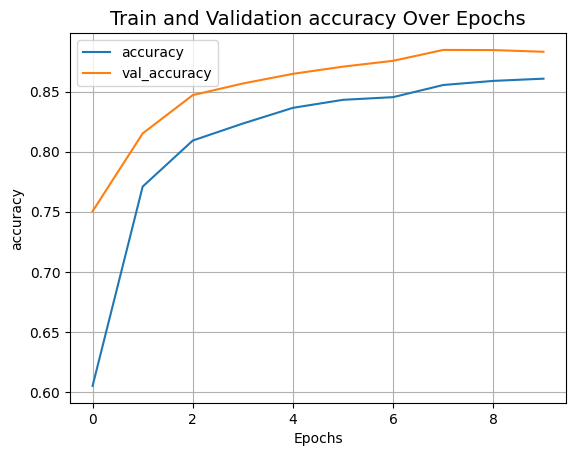

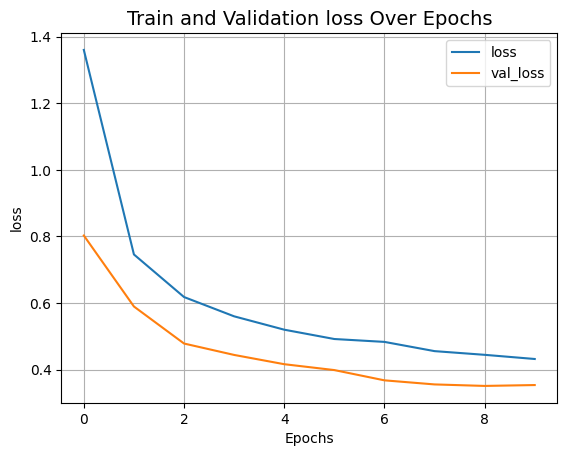

✅ Model saved: /kaggle/working/gtsrb_vit_experiment.keras
✅ History CSV saved: /kaggle/working/gtsrb_vit_experiment_history.csv
✅ Plots image saved: /kaggle/working/gtsrb_vit_experiment_plots.png

🚀 Bundle Complete. Download all matching files from the sidebar!


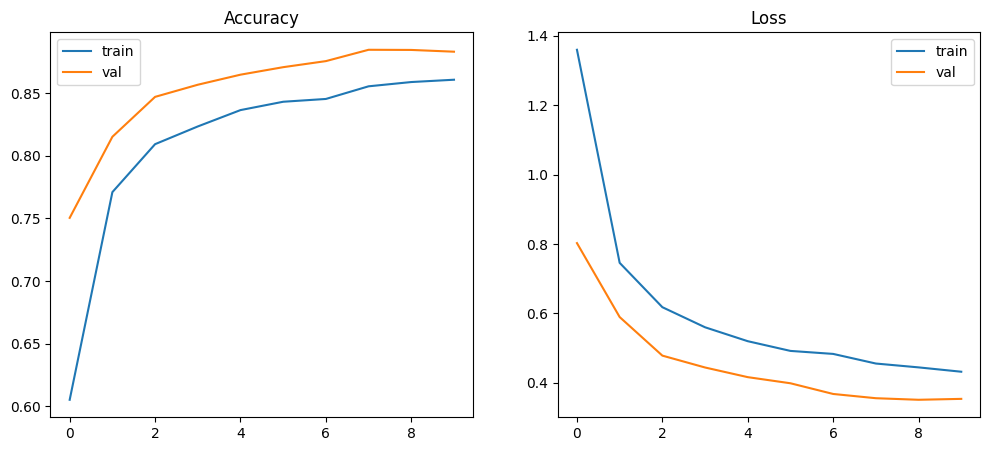

In [3]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import tensorflow as tf
import keras
from keras import layers
import keras_hub 
import matplotlib.pyplot as plt

# ==========================================
# 1. MULTI-GPU STRATEGY SETUP
# ==========================================
# This tells TensorFlow to detect and sync all available GPUs (T4 x2)
strategy = tf.distribute.MirroredStrategy()
print(f"Number of GPUs actively in use: {strategy.num_replicas_in_sync}")

# ==========================================
# 2. HYPERPARAMETERS
# ==========================================
num_classes = 43
image_size = 224 
# Global batch size of 16 = 8 images to GPU_0 and 8 images to GPU_1
global_batch_size = 16  
num_epochs = 10
learning_rate = 0.001

# ==========================================
# 3. HIGH-SPEED DATA PIPELINE
# ==========================================
DATASET_PATH = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train'

print("Loading GTSRB Dataset...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(image_size, image_size),
    batch_size=global_batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(image_size, image_size),
    batch_size=global_batch_size)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# ==========================================
# 4. ENVIRONMENTAL AUGMENTATION
# ==========================================
data_augmentation = keras.Sequential(
    [
        layers.RandomBrightness(factor=0.2),
        layers.RandomContrast(factor=0.2),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2, width_factor=0.2),
        layers.GaussianNoise(stddev=0.1)
    ],
    name="data_augmentation",
)

# Map augmentation strictly to the training set
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y), num_parallel_calls=AUTOTUNE)

# ==========================================
# 5. BUILD AND COMPILE (INSIDE GPU SCOPE)
# ==========================================
# Everything inside this 'with' block is cloned onto both graphics cards
with strategy.scope():
    print("Downloading Pre-Trained ViT via native KerasHub onto both GPUs...")
    
    model = keras_hub.models.ImageClassifier.from_preset(
        "vit_base_patch16_224_imagenet",
        num_classes=num_classes,
    )
    
    # Freeze the backbone so we only train the new classification head
    model.backbone.trainable = False
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )

# ==========================================
# 6. TRAIN AND AUTOMATICALLY SAVE
# ==========================================
print("\nStarting Multi-GPU Transfer Learning Phase...")
history = model.fit(
    train_ds,
    epochs=num_epochs,
    validation_data=val_ds,
)

# Automatically save the model to the Kaggle working directory when finished
save_path = '/kaggle/working/gtsrb_vit_transfer_multi_gpu.keras'
model.save(save_path)
print(f"\nModel successfully saved to: {save_path}")

# ==========================================
# 7. EVALUATION PLOTS
# ==========================================
def plot_history(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title(f"Train and Validation {item} Over Epochs", fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()

plot_history("accuracy")
plot_history("loss")
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define base configuration
directory = '/kaggle/working/'
base_filename = 'gtsrb_vit_experiment'
extension = '.keras'

# 2. Iteration Logic: Find the next unique version number
counter = 1
version_suffix = ""
# Start with default, then check for existing files
test_path = os.path.join(directory, f"{base_filename}{extension}")
while os.path.exists(test_path):
    version_suffix = f"_v{counter}"
    test_path = os.path.join(directory, f"{base_filename}{version_suffix}{extension}")
    counter += 1

# 3. Define the final matching paths for this specific run
final_model_path = os.path.join(directory, f"{base_filename}{version_suffix}.keras")
final_csv_path = os.path.join(directory, f"{base_filename}{version_suffix}_history.csv")
final_plot_path = os.path.join(directory, f"{base_filename}{version_suffix}_plots.png")

# --- SAVE ARTIFACT 1: The Model ---
model.save(final_model_path)
print(f"✅ Model saved: {final_model_path}")

# --- SAVE ARTIFACT 2: The Numerical Data (History) ---
# This saves every accuracy/loss point for your dissertation tables
history_df = pd.DataFrame(history.history)
history_df.to_csv(final_csv_path, index=False)
print(f"✅ History CSV saved: {final_csv_path}")

# --- SAVE ARTIFACT 3: The Plots ---
# Re-plotting ensures the image is captured and saved correctly
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()

plt.savefig(final_plot_path) # Saves the graph as a PNG
print(f"✅ Plots image saved: {final_plot_path}")

print("\n🚀 Bundle Complete. Download all matching files from the sidebar!")

In [4]:
!ls /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/

meta  Meta  Meta.csv  test  Test  Test.csv  train  Train  Train.csv


In [5]:
import tensorflow as tf
import numpy as np
import pandas as pd
import json
import os
from sklearn.metrics import classification_report

# 1. Base Paths
BASE_DIR = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/'
TEST_CSV_PATH = os.path.join(BASE_DIR, 'Test.csv')
MODEL_PATH = '/kaggle/working/gtsrb_vit_transfer_multi_gpu.keras'
OUTPUT_DIR = '/kaggle/working/'

IMG_SIZE = (224, 224)
PER_REPLICA_BATCH_SIZE = 32

# 2. Initialize Multi-GPU Strategy
# This will automatically detect all available GPUs
strategy = tf.distribute.MirroredStrategy()
num_gpus = strategy.num_replicas_in_sync
print(f"\nNumber of devices actively in use for testing: {num_gpus}")

# Scale the batch size by the number of GPUs
GLOBAL_BATCH_SIZE = PER_REPLICA_BATCH_SIZE * num_gpus

# 3. Load the CSV to map images to their true labels
print("Reading Test.csv mapping...")
test_df = pd.read_csv(TEST_CSV_PATH)
file_paths = BASE_DIR + test_df['Path'].values
original_labels = test_df['ClassId'].values

# =================================================================
# THE FIX: Translate true numerical labels to Keras alphabetical indices
# =================================================================
# 1. Create a list of the exact folder names Keras saw during training
class_folders = [str(i) for i in range(43)] 

# 2. Sort them alphabetically, exactly how Keras did
keras_sorted_folders = sorted(class_folders) 

# 3. Create a dictionary that maps True Integer -> Keras Index
# e.g., mapping folder "2" to index 12
label_mapping = {int(folder_name): index for index, folder_name in enumerate(keras_sorted_folders)}

# 4. Apply the translation to our test labels
labels = np.array([label_mapping[label] for label in original_labels])
print("Successfully translated labels to match model's internal sorting!")
# =================================================================
# print("Reading Test.csv mapping...")
# test_df = pd.read_csv(TEST_CSV_PATH)
# file_paths = BASE_DIR + test_df['Path'].values
# labels = test_df['ClassId'].values

# 4. Create a custom tf.data pipeline
def process_path(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

print("Building data pipeline...")
test_dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
test_dataset = test_dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
# Apply the globally scaled batch size
test_dataset = test_dataset.batch(GLOBAL_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 5. Load and Recompile the Model INSIDE the Strategy Scope
# This is the crucial step for multi-GPU inference
print("Loading and recompiling saved model across GPUs...")
with strategy.scope():
    model = tf.keras.models.load_model(MODEL_PATH)
    model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 6. Evaluate the model
print(f"Evaluating model on test data using {num_gpus} GPUs...")
loss, accuracy = model.evaluate(test_dataset)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# --- SAVE 1: Overall Metrics to JSON ---
metrics_dict = {
    "test_loss": float(loss),
    "test_accuracy": float(accuracy)
}
with open(os.path.join(OUTPUT_DIR, 'test_metrics.json'), 'w') as f:
    json.dump(metrics_dict, f, indent=4)
print(f"Saved overall metrics to {OUTPUT_DIR}test_metrics.json")

# 7. Generate Predictions for Reports
print("Generating predictions...")
y_pred_probs = model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = labels 

# --- SAVE 2: Classification Report to CSV ---
report_dict = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(os.path.join(OUTPUT_DIR, 'classification_report.csv'), index=True)
print(f"Saved classification report to {OUTPUT_DIR}classification_report.csv")

# --- SAVE 3: Raw Predictions to CSV ---
predictions_df = pd.DataFrame({
    'Image_File': test_df['Path'].values, 
    'True_Label': y_true,
    'Predicted_Label': y_pred,
    'Correct_Prediction': y_true == y_pred
})
predictions_df.to_csv(os.path.join(OUTPUT_DIR, 'raw_predictions.csv'), index=False)
print(f"Saved raw predictions log to {OUTPUT_DIR}raw_predictions.csv")

print("\nAll multi-GPU testing complete and results successfully saved!")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')

Number of devices actively in use for testing: 2
Reading Test.csv mapping...
Successfully translated labels to match model's internal sorting!
Building data pipeline...
Loading and recompiling saved model across GPUs...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/serialization_lib.py:734: UserWarning: `compile()` was not called as part of model loading because the model's `compile()` method is custom. All subclassed Models that have `compile()` overridden should also override `get_compile_config()` and `compile_from_config(config)`. Alternatively, you can call `compile()` manually after loading.
  instance.compile_from_config(compile_config)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Evaluating model on test data using 2 GPUs...
198/198 ━━━━━━━━━━━━━━━━━━━━ 163s 800ms/step - accuracy: 0.7036 - loss: 2.3272
Test Loss: 2.3290
Test Accuracy: 70.13%
Saved overall metrics to /kaggle/working/test_metrics.json
Generating predictions...
198/198 ━━━━━━━━━━━━━━━━━━━━ 120s 591ms/step
Saved classification report to /kaggle/working/classification_report.csv
Saved raw predictions log to /kaggle/working/raw_predictions.csv

All multi-GPU testing complete and results successfully saved!


In [6]:
#
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import keras

# ==========================================
# 1. WAKE UP BOTH GPUS (Multi-GPU Strategy)
# ==========================================
strategy = tf.distribute.MirroredStrategy()
print(f"Number of GPUs actively in use for inference: {strategy.num_replicas_in_sync}")

# ==========================================
# 2. PATHS & MEMORY-SAFE CONFIGURATION
# ==========================================
model_path = '/kaggle/input/models/ragulpalanisamy390/amja-optimised-model/keras/default/1/gtsrb_vit_transfer_multi_gpu (1).keras' 
test_dir = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test'
output_csv = '/kaggle/working/master_test_predictions.csv'

# CRITICAL FIX 1: Lower global batch size to protect VRAM (8 images per GPU)
global_batch_size = 16 

# ==========================================
# 3. LOAD MODEL INSIDE GPU SCOPE
# ==========================================
print("Loading model across both GPUs...")
with strategy.scope():
    # compile=False is used because we are only predicting, not training
    model = keras.models.load_model(model_path, compile=False)

# ==========================================
# 4. LOCATE ALL TEST IMAGES
# ==========================================
print(f"Scanning directory: {test_dir}...")
# Find all .png files and sort them alphabetically
image_filenames = [f for f in os.listdir(test_dir) if f.endswith('.png')]
image_filenames.sort()

# Create full file paths for the data pipeline
file_paths = [os.path.join(test_dir, f) for f in image_filenames]
print(f"Found {len(file_paths)} test images.")

# ==========================================
# 5. RAM-SAFE DATA PIPELINE
# ==========================================
# This function mimics load_img but runs on the CPU/GPU pipeline
def process_path(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    return img

print("Building memory-safe data pipeline...")
path_ds = tf.data.Dataset.from_tensor_slices(file_paths)
image_ds = path_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
image_ds = image_ds.batch(global_batch_size)

# CRITICAL FIX 2: Limit prefetch buffer so we don't overflow the 30GB CPU RAM.
# This forces the CPU to only prepare 2 batches ahead of the GPUs.
image_ds = image_ds.prefetch(buffer_size=2) 

# ==========================================
# 6. RUN DISTRIBUTED PREDICTION
# ==========================================
print("Running AI predictions across all images... (Both GPUs firing)")
raw_logits = model.predict(image_ds)

# ==========================================
# 7. MATH & SAVE SPREADSHEET
# ==========================================
print("Converting raw logits to percentages and formatting data...")

# Convert raw mathematical scores into 0.0 to 1.0 probabilities
probabilities = tf.nn.softmax(raw_logits).numpy()

# Get the highest score's index (The Class ID)
predicted_classes = np.argmax(probabilities, axis=1)

# Get the actual percentage confidence of that top guess (e.g., 0.985 -> 98.5%)
confidence_scores = np.max(probabilities, axis=1) * 100

# Create a Pandas DataFrame to organize the data neatly
results_df = pd.DataFrame({
    'Filename': image_filenames,
    'Predicted_Class': predicted_classes,
    'Confidence_Percentage': np.round(confidence_scores, 2)
})

# Save to CSV
results_df.to_csv(output_csv, index=False)

print(f"\n✅ SUCCESS! Master spreadsheet saved to: {output_csv}")
print("Check your Kaggle 'Output' sidebar to download the CSV.")
print(results_df.head(5))

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of GPUs actively in use for inference: 2
Loading model across both GPUs...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Scanning directory: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test...
Found 12630 test images.
Building memory-safe data pipeline...
Running AI predictions across all images... (Both GPUs firing)
790/790 ━━━━━━━━━━━━━━━━━━━━ 123s 152ms/step
Converting raw logits to percentages and formatting data...

✅ SUCCESS! Master spreadsheet saved to: /kaggle/working/master_test_predictions.csv
Check your Kaggle 'Output' sidebar to download the CSV.
    Filename  Predicted_Class  Confidence_Percentage
0  00000.png                8              94.230003
1  00001.png                1              98.080002
2  00002.png               32              94.730003
3  00003.png               28              96.730003
4  00004.png                3              97.879997


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
GPUs actively in use: 2
Loading official answer key...
Building high-speed memory-safe pipeline...
Loading model and analyzing 12,630 images across both GPUs...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


790/790 ━━━━━━━━━━━━━━━━━━━━ 122s 151ms/step

🏆 FINAL OFFICIAL TEST ACCURACY: 3.74%
✅ Full performance metrics saved to: /kaggle/working/dissertation_final_results/official_classification_report.txt
Drawing High-Resolution Confusion Matrix...


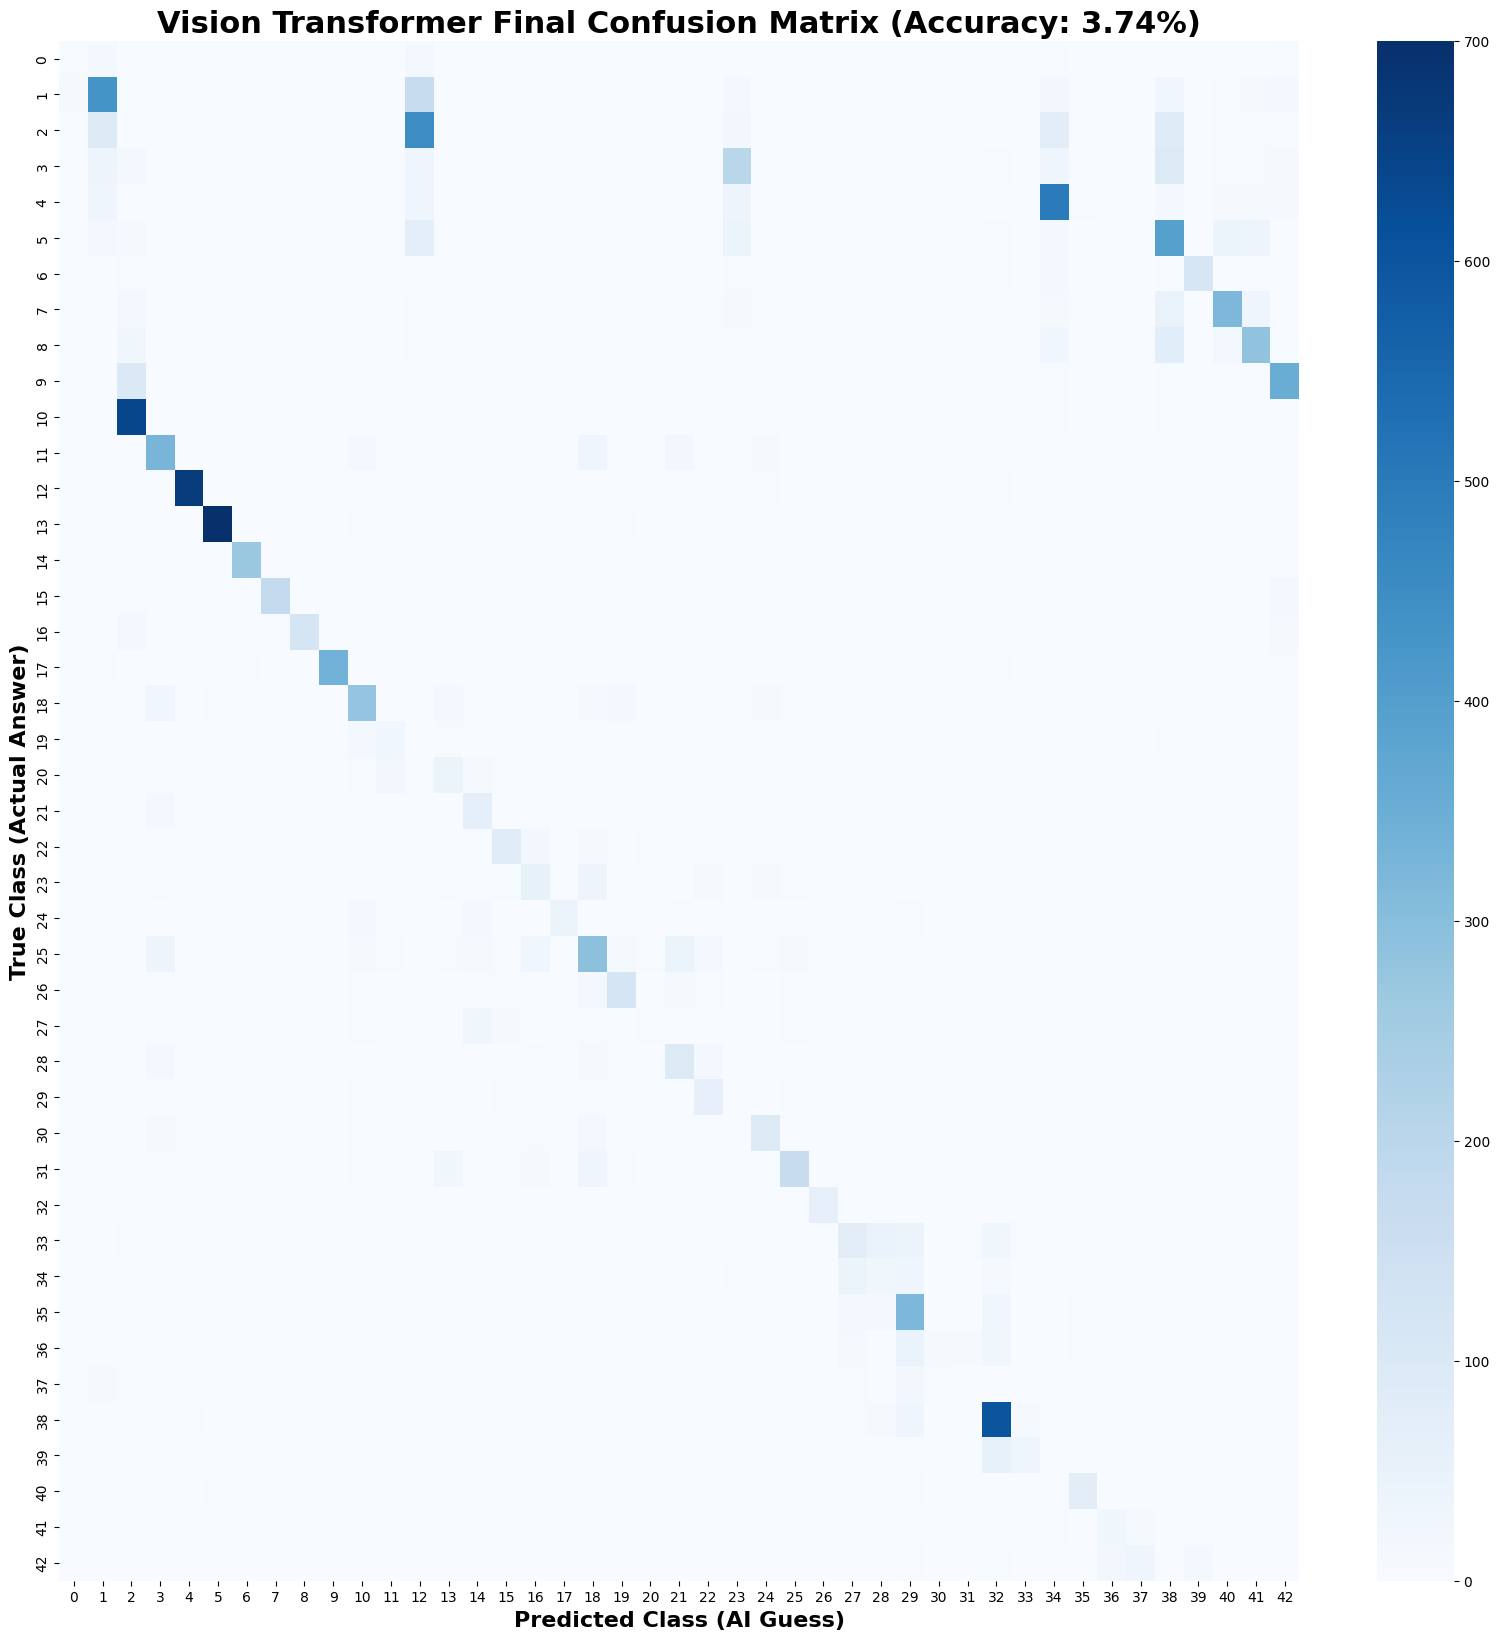

✅ Confusion Matrix saved to: /kaggle/working/dissertation_final_results/final_confusion_matrix.png

🚀 EVALUATION COMPLETE. You can download all files from the 'Output' sidebar.


In [7]:
#wrong one
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# 1. WAKE UP MULTI-GPU STRATEGY
# ==========================================
strategy = tf.distribute.MirroredStrategy()
print(f"GPUs actively in use: {strategy.num_replicas_in_sync}")

# ==========================================
# 2. PATHS & DIRECTORIES
# ==========================================
# Base dataset directory
base_dir = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign'
truth_csv_path = os.path.join(base_dir, 'Test.csv')
model_path = '/kaggle/input/models/ragulpalanisamy390/amja-optimised-model/keras/default/1/gtsrb_vit_transfer_multi_gpu (1).keras'

# Create a master folder for your dissertation artifacts
output_dir = '/kaggle/working/dissertation_final_results'
os.makedirs(output_dir, exist_ok=True)

# ==========================================
# 3. LOAD GROUND TRUTH (ANSWER KEY)
# ==========================================
print("Loading official answer key...")
truth_df = pd.read_csv(truth_csv_path)

# Extract the true answers and build the exact file paths
y_true = truth_df['ClassId'].values
# The CSV writes paths as 'Test/00000.png', so we attach the base_dir to it
file_paths = [os.path.join(base_dir, path) for path in truth_df['Path']]

# ==========================================
# 4. RAM-SAFE MULTI-GPU DATA PIPELINE
# ==========================================
def process_path(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    return img

global_batch_size = 16

print("Building high-speed memory-safe pipeline...")
path_ds = tf.data.Dataset.from_tensor_slices(file_paths)
image_ds = path_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
image_ds = image_ds.batch(global_batch_size).prefetch(buffer_size=2)

# ==========================================
# 5. DISTRIBUTED INFERENCE
# ==========================================
print("Loading model and analyzing 12,630 images across both GPUs...")
with strategy.scope():
    model = keras.models.load_model(model_path, compile=False)

# Get the raw predictions and convert to class IDs
raw_logits = model.predict(image_ds)
y_pred = np.argmax(raw_logits, axis=1)

# ==========================================
# 6. CALCULATE FINAL ACCURACY & SAVE METRICS
# ==========================================
final_accuracy = accuracy_score(y_true, y_pred)
print(f"\n==================================================")
print(f"🏆 FINAL OFFICIAL TEST ACCURACY: {final_accuracy * 100:.2f}%")
print(f"==================================================")

# Generate and save the massive classification report (Precision/Recall for all 43 classes)
report = classification_report(y_true, y_pred)
report_path = os.path.join(output_dir, 'official_classification_report.txt')

with open(report_path, 'w') as f:
    f.write(f"--- VISION TRANSFORMER EVALUATION ---\n")
    f.write(f"Final Test Accuracy: {final_accuracy * 100:.2f}%\n\n")
    f.write(report)
print(f"✅ Full performance metrics saved to: {report_path}")

# ==========================================
# 7. GENERATE & SAVE CONFUSION MATRIX
# ==========================================
print("Drawing High-Resolution Confusion Matrix...")
plt.figure(figsize=(20, 20)) # 20x20 inches for extreme clarity
cm = confusion_matrix(y_true, y_pred)

# Draw the heatmap
sns.heatmap(cm, annot=False, cmap='Blues', fmt='g')

plt.xlabel('Predicted Class (AI Guess)', fontsize=16, fontweight='bold')
plt.ylabel('True Class (Actual Answer)', fontsize=16, fontweight='bold')
plt.title(f'Vision Transformer Final Confusion Matrix (Accuracy: {final_accuracy * 100:.2f}%)', fontsize=22, fontweight='bold')

# Save as a print-quality PNG for your document
cm_save_path = os.path.join(output_dir, 'final_confusion_matrix.png')
plt.savefig(cm_save_path, bbox_inches='tight', dpi=300)
plt.show()

print(f"✅ Confusion Matrix saved to: {cm_save_path}")
print("\n🚀 EVALUATION COMPLETE. You can download all files from the 'Output' sidebar.")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
GPUs actively in use: 2
Decoder ring built. Ready to translate AI outputs to correct Class IDs.
Loading official answer key...
Building high-speed memory-safe pipeline...
Loading model and analyzing 12,630 images across both GPUs...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


790/790 ━━━━━━━━━━━━━━━━━━━━ 122s 151ms/step
Translating internal indices to correct German Traffic Sign IDs...

🏆 TRUE OFFICIAL TEST ACCURACY: 71.15%
✅ Full performance metrics saved to: /kaggle/working/dissertation_final_results/official_classification_report_corrected.txt
Drawing High-Resolution Confusion Matrix...


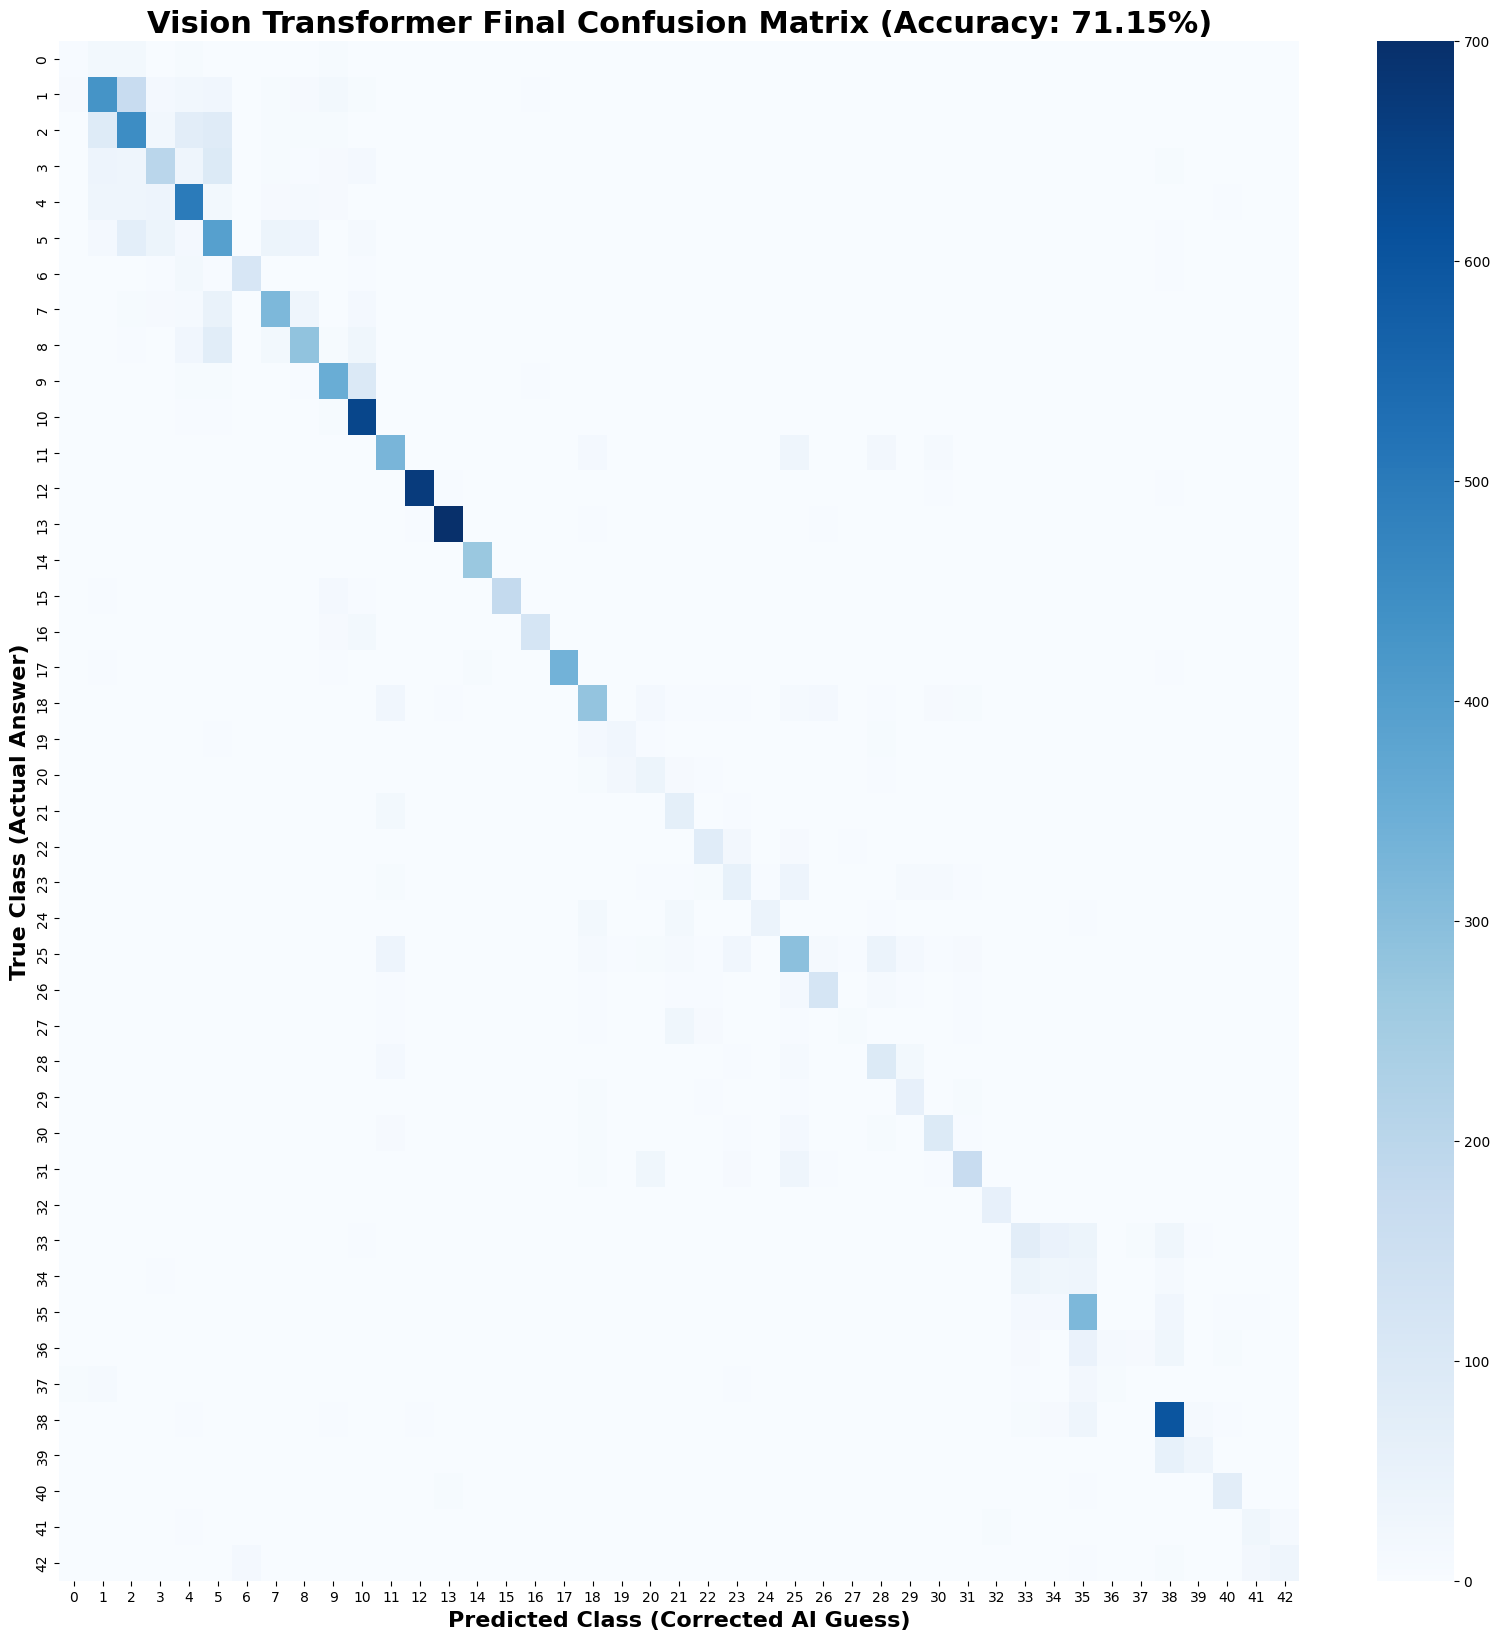

✅ Confusion Matrix saved to: /kaggle/working/dissertation_final_results/final_confusion_matrix_corrected.png

🚀 EVALUATION COMPLETE. Your artifacts are ready in the 'Output' sidebar!


In [8]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# 1. WAKE UP MULTI-GPU STRATEGY
# ==========================================
strategy = tf.distribute.MirroredStrategy()
print(f"GPUs actively in use: {strategy.num_replicas_in_sync}")

# ==========================================
# 2. PATHS & DIRECTORIES
# ==========================================
base_dir = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign'
train_dir = os.path.join(base_dir, 'Train')
truth_csv_path = os.path.join(base_dir, 'Test.csv')
model_path = '/kaggle/input/models/ragulpalanisamy390/amja-optimised-model/keras/default/1/gtsrb_vit_transfer_multi_gpu (1).keras'

# Create a master folder for your dissertation artifacts
output_dir = '/kaggle/working/dissertation_final_results'
os.makedirs(output_dir, exist_ok=True)

# ==========================================
# 3. BUILD THE "MAGIC DECODER RING"
# ==========================================
# Recreate Keras's alphanumeric sorting so we can translate the AI's guesses
keras_class_names = sorted(os.listdir(train_dir))
print("Decoder ring built. Ready to translate AI outputs to correct Class IDs.")

# ==========================================
# 4. LOAD GROUND TRUTH (ANSWER KEY)
# ==========================================
print("Loading official answer key...")
truth_df = pd.read_csv(truth_csv_path)

# Extract the true answers and build the exact file paths
y_true = truth_df['ClassId'].values
file_paths = [os.path.join(base_dir, path) for path in truth_df['Path']]

# ==========================================
# 5. RAM-SAFE MULTI-GPU DATA PIPELINE
# ==========================================
def process_path(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    return img

global_batch_size = 16

print("Building high-speed memory-safe pipeline...")
path_ds = tf.data.Dataset.from_tensor_slices(file_paths)
image_ds = path_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
image_ds = image_ds.batch(global_batch_size).prefetch(buffer_size=2)

# ==========================================
# 6. DISTRIBUTED INFERENCE
# ==========================================
print("Loading model and analyzing 12,630 images across both GPUs...")
with strategy.scope():
    model = keras.models.load_model(model_path, compile=False)

# Get the raw predictions (indices)
raw_logits = model.predict(image_ds)
raw_predicted_indices = np.argmax(raw_logits, axis=1)

# ==========================================
# 7. TRANSLATE THE PREDICTIONS
# ==========================================
print("Translating internal indices to correct German Traffic Sign IDs...")
# Map the wrong index (e.g., 2) to the correct folder string ('10'), then to an integer (10)
y_pred_corrected = [int(keras_class_names[idx]) for idx in raw_predicted_indices]

# ==========================================
# 8. CALCULATE FINAL ACCURACY & SAVE METRICS
# ==========================================
final_accuracy = accuracy_score(y_true, y_pred_corrected)
print(f"\n==================================================")
print(f"🏆 TRUE OFFICIAL TEST ACCURACY: {final_accuracy * 100:.2f}%")
print(f"==================================================")

# Generate and save the classification report
report = classification_report(y_true, y_pred_corrected)
report_path = os.path.join(output_dir, 'official_classification_report_corrected.txt')

with open(report_path, 'w') as f:
    f.write(f"--- VISION TRANSFORMER FINAL EVALUATION ---\n")
    f.write(f"Final True Test Accuracy: {final_accuracy * 100:.2f}%\n\n")
    f.write(report)
print(f"✅ Full performance metrics saved to: {report_path}")

# ==========================================
# 9. GENERATE & SAVE CONFUSION MATRIX
# ==========================================
print("Drawing High-Resolution Confusion Matrix...")
plt.figure(figsize=(20, 20)) # 20x20 inches for extreme clarity
cm = confusion_matrix(y_true, y_pred_corrected)

# Draw the heatmap
sns.heatmap(cm, annot=False, cmap='Blues', fmt='g')

plt.xlabel('Predicted Class (Corrected AI Guess)', fontsize=16, fontweight='bold')
plt.ylabel('True Class (Actual Answer)', fontsize=16, fontweight='bold')
plt.title(f'Vision Transformer Final Confusion Matrix (Accuracy: {final_accuracy * 100:.2f}%)', fontsize=22, fontweight='bold')

# Save as a print-quality PNG for your document
cm_save_path = os.path.join(output_dir, 'final_confusion_matrix_corrected.png')
plt.savefig(cm_save_path, bbox_inches='tight', dpi=300)
plt.show()

print(f"✅ Confusion Matrix saved to: {cm_save_path}")
print("\n🚀 EVALUATION COMPLETE. Your artifacts are ready in the 'Output' sidebar!")